ピクセル数 (N): 6400, バンド数 (M): 17
画像サイズ: H=80, W=80


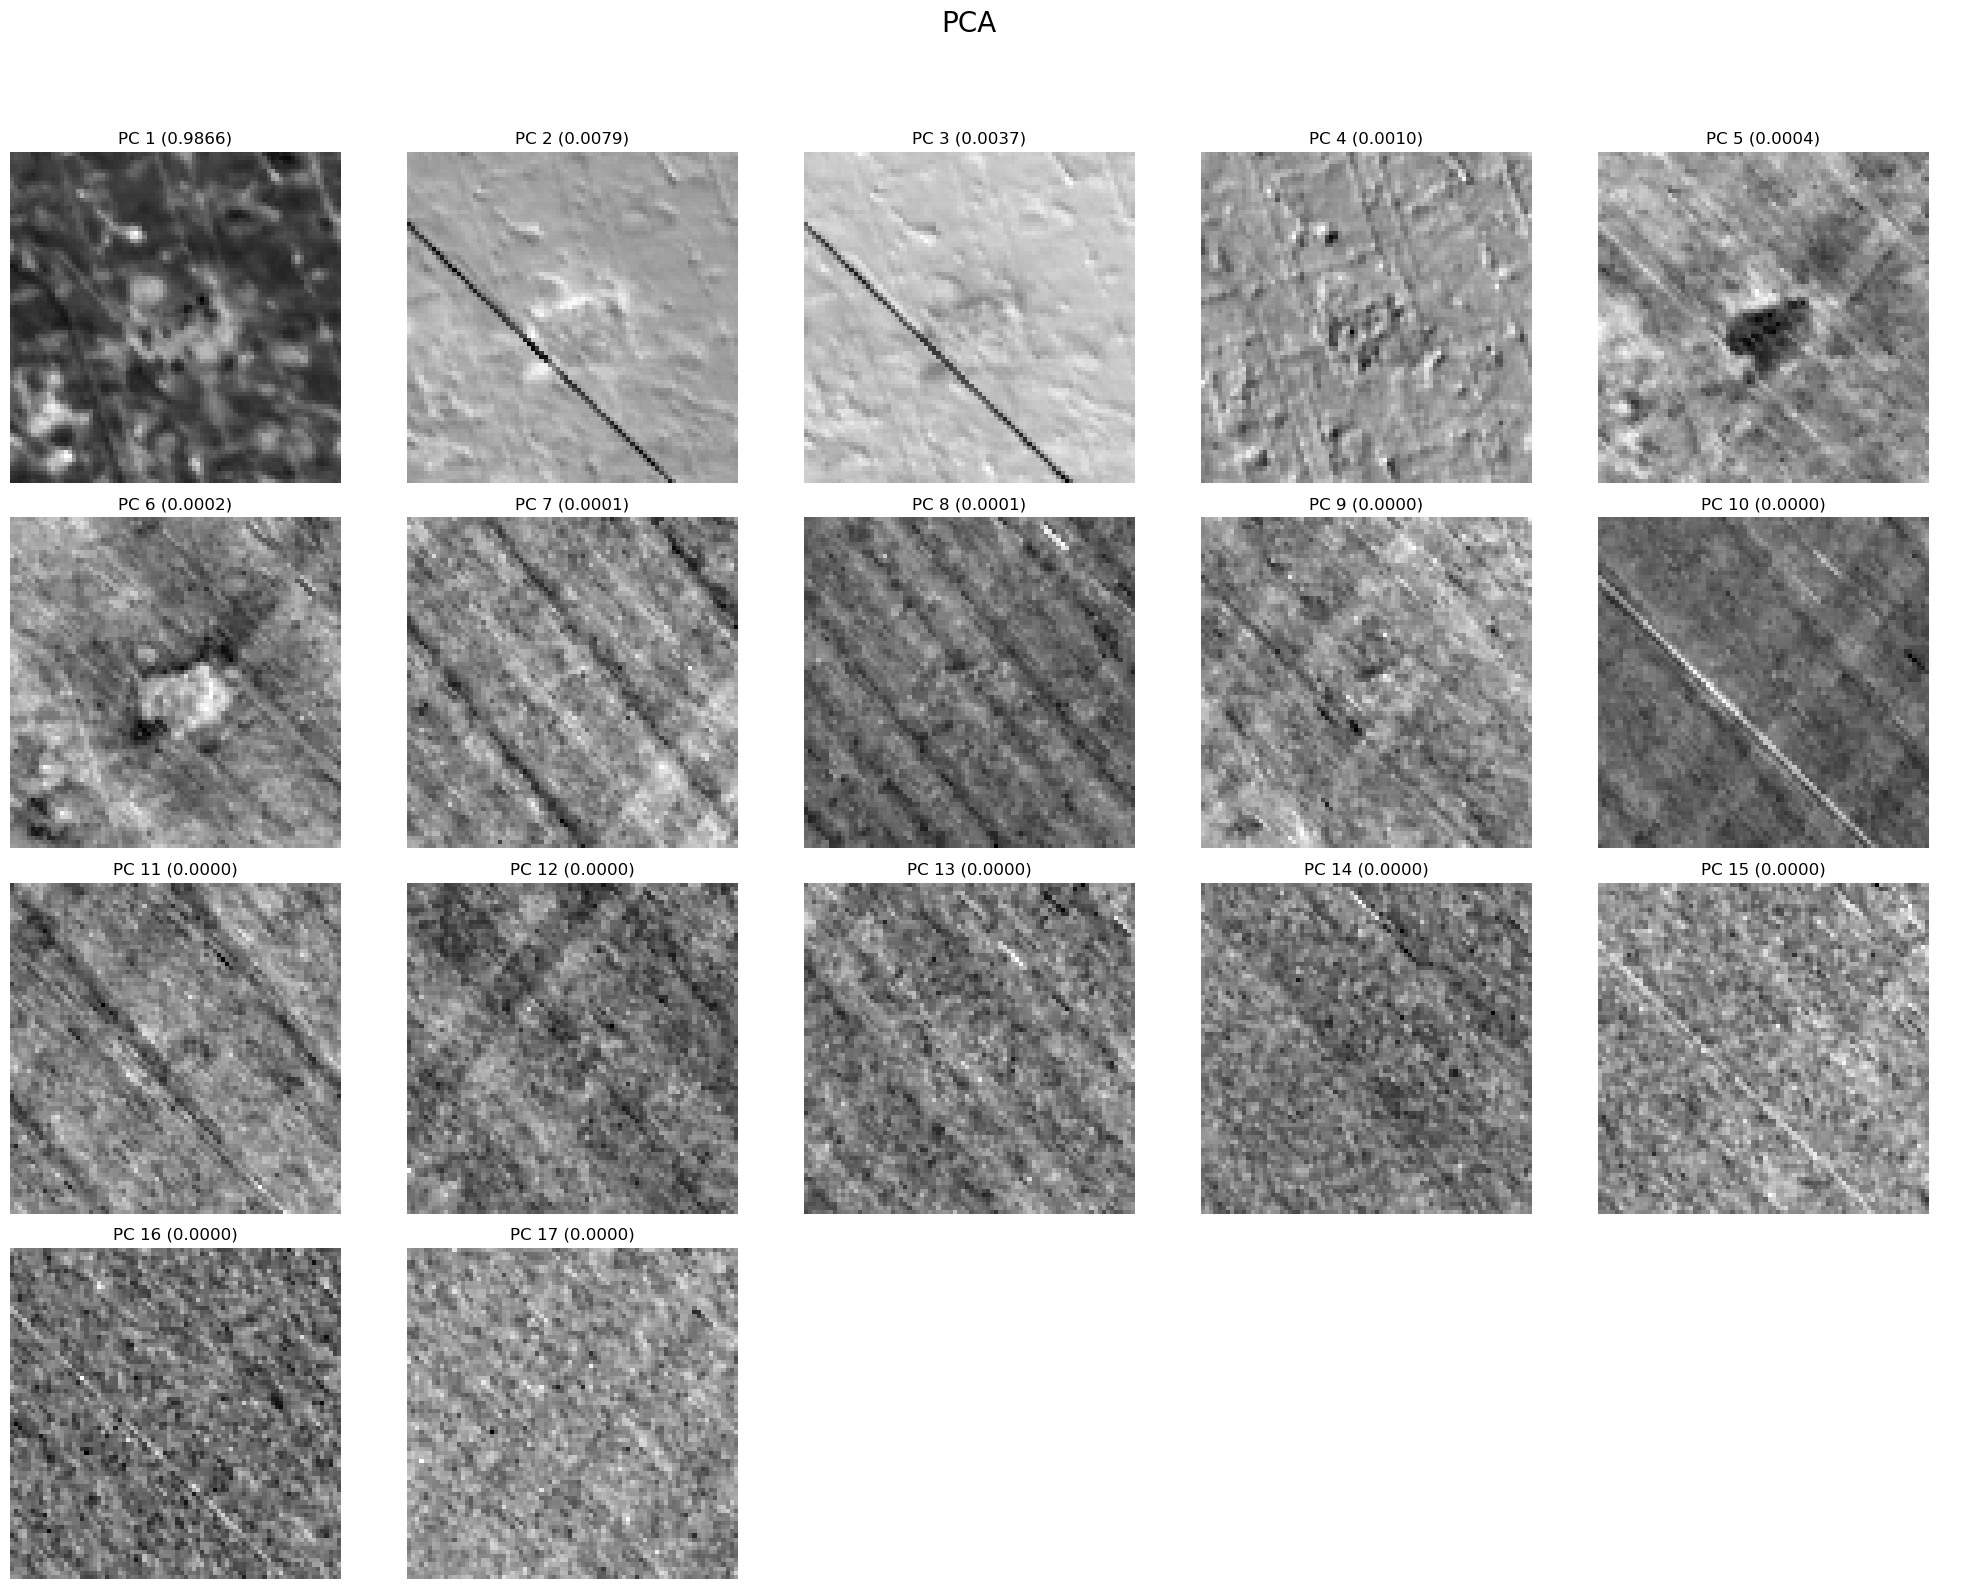

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = r"E:\refit\all_roi_spectra.csv" # データの読み込み
df = pd.read_csv(file_path)

y_coords = df.iloc[:, 0].values.astype(int) # 座標とスペクトルデータに分離
x_coords = df.iloc[:, 1].values.astype(int) # 1列目y, 2列目x
# ... (df = pd.read_csv(...) の後) ...

# 'DS', 'DT', 'DU' のような複数の列を名前で選択
column_list = ['wave_1025.91nm','wave_1038.40nm','wave_1050.89nm','wave_1063.38nm','wave_1075.88nm','wave_1088.37nm','wave_1100.86nm','wave_1113.35nm','wave_1125.84nm','wave_1138.33nm','wave_1150.82nm','wave_1163.31nm','wave_1175.80nm','wave_1188.29nm','wave_1200.78nm','wave_1213.27nm','wave_1225.76nm']  
#column_list = ['wave_2187.49nm','wave_2199.97nm','wave_2212.47nm','wave_2224.95nm','wave_2237.45nm','wave_2249.93nm','wave_2262.43nm','wave_2274.91nm','wave_2287.41nm','wave_2299.89nm','wave_2312.39nm','wave_2324.88nm','wave_2337.36nm','wave_2349.86nm','wave_2362.34nm']
#column_list = ['wave_1600.45nm','wave_1612.94nm','wave_1625.43nm','wave_1637.92nm','wave_1650.41nm','wave_1662.90nm','wave_1675.39nm','wave_1687.88nm','wave_1700.38nm','wave_1712.87nm','wave_1725.36nm','wave_1737.85nm','wave_1750.34nm']
spectral_data = df[column_list].values

# これで spectral_data は (ピクセル数, 3) の2次元配列になり、
# PCAにかけることができます。

# ... (この後の処理) ...

#spectral_data = df.iloc[:, 2:].values # 3列目以降をスペクトルデータとしてNumPy配列に変換

n_pixels, n_bands = spectral_data.shape # ピクセル数 (N) と バンド数 (M)
print(f"ピクセル数 (N): {n_pixels}, バンド数 (M): {n_bands}")
H = y_coords.max() + 1
W = x_coords.max() + 1
print(f"画像サイズ: H={H}, W={W}")

mean = np.mean(spectral_data, axis=0) # 各バンド(列)の平均値を計算.axis=0 は列ごとの計算
std = np.std(spectral_data, axis=0) # 各バンドの標準偏差を計算
std[std == 0] = 1.0
scaled_data = (spectral_data - mean) / std # 標準化(X - mean) / std　　サンプル数　x　特徴量
cov_matrix = np.cov(scaled_data.T) # 共分散行列の計算。バンド間の関連性の強さ。cov:(特徴量 x サンプル数)より転置

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # 固有ベクトルと固有値、eigenvectorsの各「列」が1つの固有ベクトルに対応

sorted_indices = np.argsort(eigenvalues)[::-1] # 固有値を降順に
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices] # 列を並べ替え、新しい軸

explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues) # 寄与率
pca_results_np = scaled_data.dot(sorted_eigenvectors) # 回転後、(PC1の値,PC2の値......)

pca_image_stack = np.full((H, W, n_bands), np.nan)
pca_image_stack[y_coords, x_coords] = pca_results_np

ncols = 5
nrows = int(np.ceil(n_bands / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4))
fig.suptitle('PCA', fontsize=20, y=1.02)

for i in range(n_bands):
    if nrows > 1:
        ax = axes.flat[i]
    else:
        # 1行の場合
        ax = axes[i] if n_bands > 1 else axes 

    img_data = pca_image_stack[:, :, i]
    ax.imshow(img_data, cmap='gray')
    ax.set_title(f'PC {i+1} ({explained_variance_ratio[i]:.4f})')
    ax.axis('off')
    
# 使わないサブプロットを非表示
for i in range(n_bands, len(axes.flat)):
    axes.flat[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

ピクセル数 (N): 6400, バンド数 (M): 2
画像サイズ: H=80, W=80


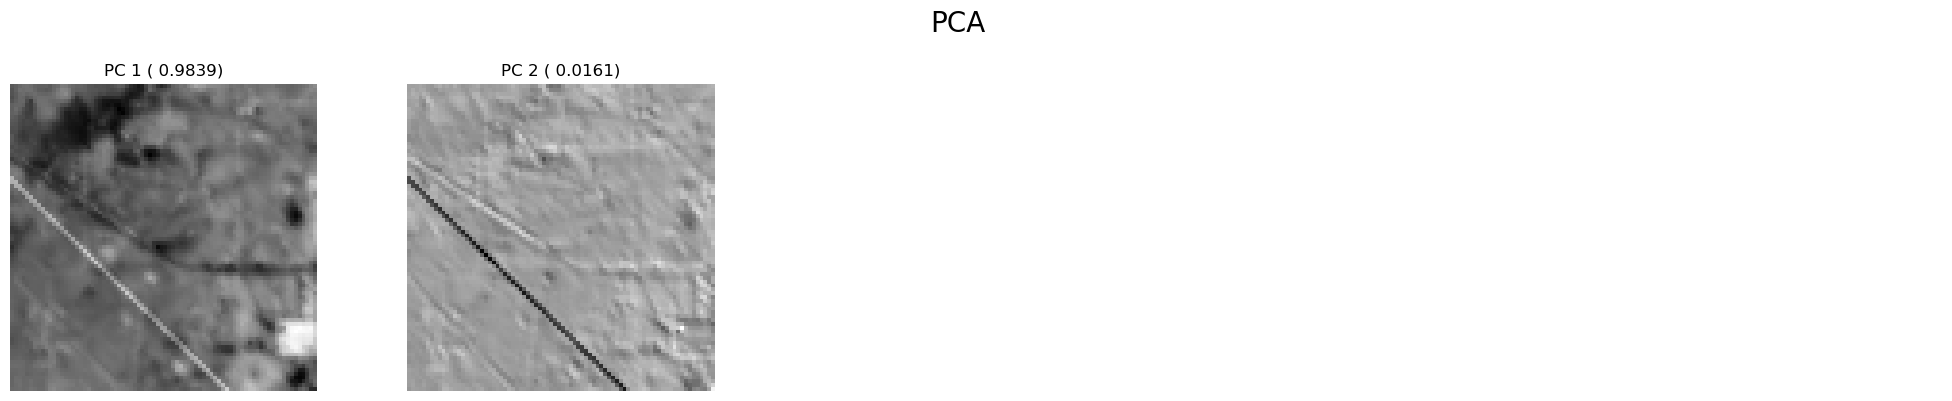

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


file_path = r"E:\refit\all_ir_spectra.csv" # データの読み込み
df = pd.read_csv(file_path)

y_coords = df.iloc[:, 0].values.astype(int) # 座標とスペクトルデータに分離
x_coords = df.iloc[:, 1].values.astype(int) # 1列目y, 2列目x
# ... (df = pd.read_csv(...) の後) ...

# 'DS', 'DT', 'DU' のような複数の列を名前で選択
column_list = ['wave_1675.39nm','wave_2174.99nm']  # <-- 例です。使いたい列名に置き換えてください
spectral_data = df[column_list].values

# これで spectral_data は (ピクセル数, 3) の2次元配列になり、
# PCAにかけることができます。

# ... (この後の処理) ...

#spectral_data = df.iloc[:, 2:].values # 3列目以降をスペクトルデータとしてNumPy配列に変換

n_pixels, n_bands = spectral_data.shape # ピクセル数 (N) と バンド数 (M)
print(f"ピクセル数 (N): {n_pixels}, バンド数 (M): {n_bands}")
H = y_coords.max() + 1
W = x_coords.max() + 1
print(f"画像サイズ: H={H}, W={W}")

mean = np.mean(spectral_data, axis=0) # 各バンド(列)の平均値を計算.axis=0 は列ごとの計算
std = np.std(spectral_data, axis=0) # 各バンドの標準偏差を計算
std[std == 0] = 1.0
scaled_data = (spectral_data - mean) # 標準化(X - mean) / std　　サンプル数　x　特徴量
cov_matrix = np.cov(scaled_data.T) # 共分散行列の計算。バンド間の関連性の強さ。cov:(特徴量 x サンプル数)より転置

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix) # 固有ベクトルと固有値、eigenvectorsの各「列」が1つの固有ベクトルに対応

sorted_indices = np.argsort(eigenvalues)[::-1] # 固有値を降順に
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices] # 列を並べ替え、新しい軸

explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues) # 寄与率
pca_results_np = scaled_data.dot(sorted_eigenvectors) # 回転後、(PC1の値,PC2の値......)

pca_image_stack = np.full((H, W, n_bands), np.nan)
pca_image_stack[y_coords, x_coords] = pca_results_np

ncols = 5
nrows = int(np.ceil(n_bands / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4))
fig.suptitle('PCA', fontsize=20, y=1.02)

for i in range(n_bands):
    if nrows > 1:
        ax = axes.flat[i]
    else:
        # 1行の場合
        ax = axes[i] if n_bands > 1 else axes 

    img_data = pca_image_stack[:, :, i]
    ax.imshow(img_data, cmap='gray')
    ax.set_title(f'PC {i+1} ( {explained_variance_ratio[i]:.4f})')
    ax.axis('off')
    
# 使わないサブプロットを非表示
for i in range(n_bands, len(axes.flat)):
    axes.flat[i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

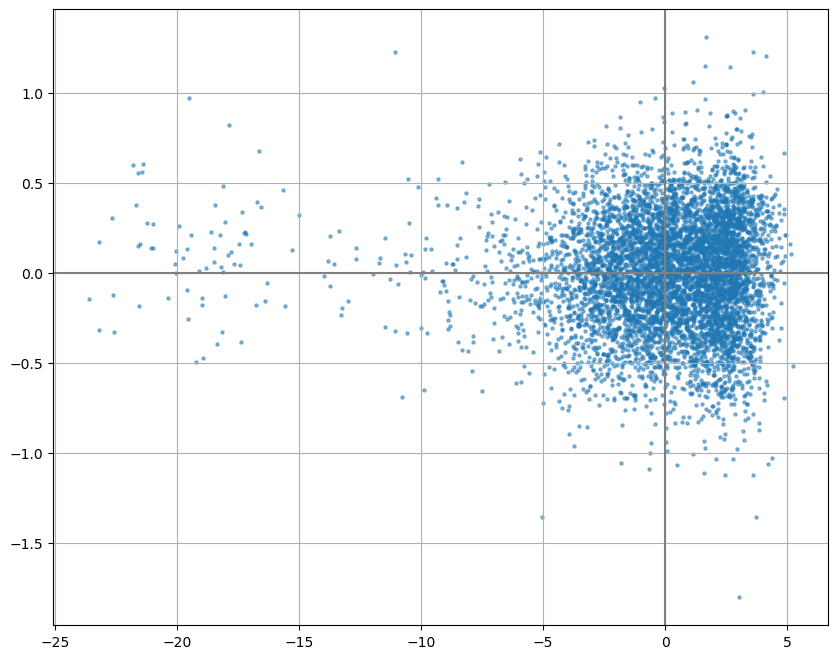

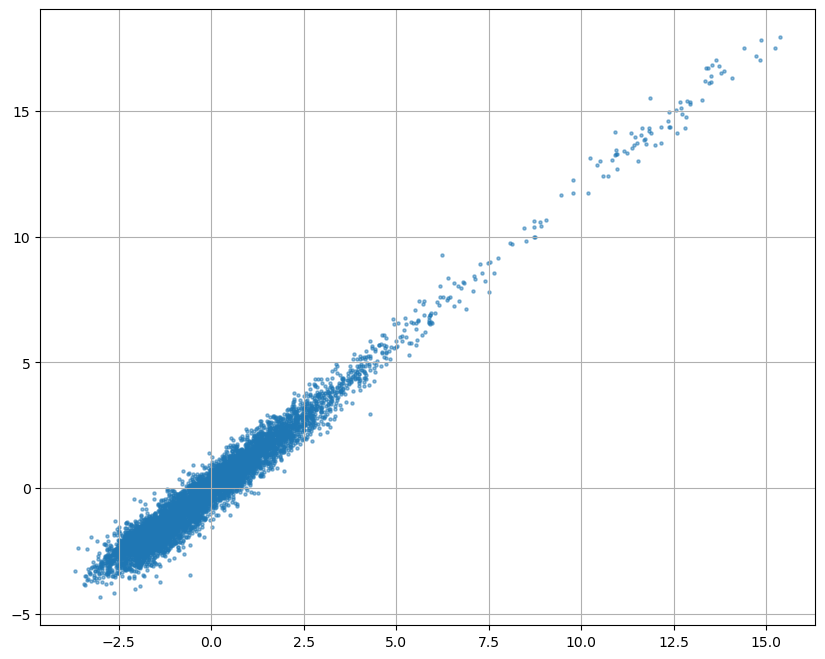

In [3]:
band_names_for_2d_pca = df.columns[2:4].tolist()
spectral_data_2bands = df[band_names_for_2d_pca].values
n_pix, n_band = spectral_data_2bands.shape
mean_vec_2bands = np.mean(spectral_data_2bands, axis=0)
std_vec_2bands = np.std(spectral_data_2bands, axis=0)
std_vec_2bands[std_vec_2bands == 0] = 1
scaled_data_2bands = (spectral_data_2bands - mean_vec_2bands) 

cov_matrix_2bands = np.cov(scaled_data_2bands.T)

eigenvalues_2bands, eigenvectors_2bands = np.linalg.eig(cov_matrix_2bands)

sorted_indices_2bands = np.argsort(eigenvalues_2bands)[::-1]
sorted_eigenvalues_2bands = eigenvalues_2bands[sorted_indices_2bands]
sorted_eigenvectors_2bands = eigenvectors_2bands[:, sorted_indices_2bands]

pca_results_2bands = scaled_data_2bands.dot(sorted_eigenvectors_2bands)

pc1 = pca_results_2bands[:,0]
pc2 = pca_results_2bands[:,1]

plt.figure(figsize=(10,8))
plt.scatter(pc1,pc2,s=5,alpha=0.5)
plt.grid(True)
plt.axhline(0, color='gray')
plt.axvline(0, color='gray')
plt.show()

plt.figure(figsize=(10,8))
plt.scatter(scaled_data_2bands[:,0], scaled_data_2bands[:,1], s=5, alpha=0.5)
plt.grid(True)
plt.show()